In [1]:
!sudo apt-get update && sudo apt-get install -y default-jdk


Hit:1 https://download.docker.com/linux/debian bullseye InRelease
Hit:2 https://deb.debian.org/debian bullseye InRelease              
Hit:3 https://packages.cloud.google.com/apt gcsfuse-bullseye InRelease
Get:4 https://nvidia.github.io/libnvidia-container/stable/deb/amd64  InRelease [1477 B]
Hit:5 https://deb.debian.org/debian-security bullseye-security InRelease
Hit:6 https://deb.debian.org/debian bullseye-updates InRelease
Hit:7 https://packages.cloud.google.com/apt google-compute-engine-bullseye-stable InRelease
Hit:8 https://packages.cloud.google.com/apt cloud-sdk-bullseye InRelease
Hit:9 https://packages.cloud.google.com/apt google-fast-socket InRelease
Fetched 1477 B in 1s (1170 B/s)
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
default-jdk is already the newest version (2:1.11-72).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.


In [2]:
import os
import subprocess

# This tells Python to look in the standard Linux location for Java tools
os.environ['PATH'] += ':/usr/lib/jvm/default-java/bin'

# Check if it works now
try:
    version = subprocess.check_output(['javac', '-version'], stderr=subprocess.STDOUT)
    print(f"Success! {version.decode()}")
except Exception:
    print("Still can't find javac. Try restarting the Kernel.")


Success! javac 11.0.30



In [3]:
%pip install -r requirements.txt

Ignoring appnope: markers 'sys_platform == "darwin"' don't match your environment
Ignoring contourpy: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring ipython: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring ipython-pygments-lexers: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring networkx: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring numpy: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring pandas: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring pywinpty: markers 'os_name == "nt"' don't match your environment
Ignoring scikit-learn: markers 'python_full_version >= "3.11"' don't match your environment
Ignoring scipy: markers 'python_full_version >= "3.11"' don't match your environment
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print(sys.version)
import os
import json
import py_vncorenlp

from pathlib import Path
from pprint import pprint
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    AutoModel,
)
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import matplotlib.pyplot as plt

3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]


In [5]:
# ASPECTS = ["giảng_viên", "chương_trình", "trang_thiết_bị", "khác"]
# SENTIMENTS = ["negative", "neutral", "positive"]
ds = load_dataset("uitnlp/vietnamese_students_feedback")


def examine_dataset_simple(ds, show_feature=True):
    print("=== DATASET ===")
    print(ds)

    if show_feature:
        print("\n=== FEATURES ===")
        features_dict = ds["train"].features.to_dict()
        print(json.dumps(features_dict, indent=4, ensure_ascii=False))

    print("\n=== FIRST SAMPLE ===")
    readable = {
        k: v.tolist() if hasattr(v, "tolist") else v
        for k, v in ds["train"][0].items()
    }

    pprint(readable)


examine_dataset_simple(ds)

=== DATASET ===
DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 3166
    })
})

=== FEATURES ===
{
    "sentence": {
        "dtype": "string",
        "_type": "Value"
    },
    "sentiment": {
        "names": [
            "negative",
            "neutral",
            "positive"
        ],
        "_type": "ClassLabel"
    },
    "topic": {
        "names": [
            "lecturer",
            "training_program",
            "facility",
            "others"
        ],
        "_type": "ClassLabel"
    }
}

=== FIRST SAMPLE ===
{'sentence': 'slide giáo trình đầy đủ .', 'sentiment': 2, 'topic': 1}


In [6]:

cwd = Path.cwd()

# Define the ABSOLUTE path
save_dir = (cwd / "vncorenlp").resolve()

# Manually create the parent directory first
# The library's download_model fails because it can't create /vncorenlp/models 
# if /vncorenlp doesn't exist yet.
save_dir.mkdir(parents=True, exist_ok=True)

if not (save_dir / "models").exists():
    print(f"Downloading models to {save_dir}...")
    # The command below tried to run a command like: Create folder "models" inside "vncorenlp"
    # BUT it does not create the "vncorenlp" folder.
    # VERY VERY FRUSTRATING
    py_vncorenlp.download_model(save_dir=save_dir.as_posix())
else:
    print("Models already exist, skipping download.")


try:
    rdrsegmenter = py_vncorenlp.VnCoreNLP(
        annotators=["wseg"], 
        save_dir=save_dir.as_posix()
    )
    print("Segmenter loaded successfully!")
except Exception as e:
    print(f"Error loading segmenter: {e}")

os.chdir(cwd)
print(Path.cwd())


Models already exist, skipping download.
2026-03-13 15:39:20 INFO  WordSegmenter:24 - Loading Word Segmentation model
Segmenter loaded successfully!
/home/jupyter


In [7]:


def segment_text(example):
    """
    Input:
        [
            "môn học này rất tuyệt, vừa học được lý thuyết.",
            "thầy dạy chậm rãi."
        ]
    Output:
        [
            "môn_học này rất tuyệt , vừa học được lý_thuyết .",
            "thầy dạy chậm_rãi ."
        ]
    """
    sentence = example["sentence"]

    # if the input sentence contains ".",
    # the sentence result will be separated.
    dot_separated_segmented_sentences = rdrsegmenter.word_segment(sentence)

    # Join back into a single string with spaces
    example["sentence"] = " ".join(dot_separated_segmented_sentences)
    return example

ds_segmented = ds.map(segment_text)
examine_dataset_simple(ds_segmented)

Parameter 'function'=<function segment_text at 0x7f47df6c1360> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/11426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

=== DATASET ===
DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 3166
    })
})

=== FEATURES ===
{
    "sentence": {
        "dtype": "string",
        "_type": "Value"
    },
    "sentiment": {
        "names": [
            "negative",
            "neutral",
            "positive"
        ],
        "_type": "ClassLabel"
    },
    "topic": {
        "names": [
            "lecturer",
            "training_program",
            "facility",
            "others"
        ],
        "_type": "ClassLabel"
    }
}

=== FIRST SAMPLE ===
{'sentence': 'slide giáo_trình đầy_đủ .', 'sentiment': 2, 'topic': 1}


In [8]:

# %%
# 4 aspects
topic_map = {
    0: "lecturer",
    1: "training_program",
    2: "facility",
    3: "others",
}
# topic_map = {
#     0: "giảng_viên",
#     1: "chương_trình",
#     2: "trang_thiết_bị",
#     3: "khác",
# }


idx2sentiment = {0: "negative", 1: "neutral", 2: "positive", 3: "none"}
sentiment2idx = {v: k for k, v in idx2sentiment.items()}

backbone_model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(backbone_model_name)


def preprocess_function(examples):
    # IMPORTANT: Ensure examples["sentence"] is ALREADY word-segmented

    model_inputs = tokenizer(
        examples["sentence"],
        padding=False,
        truncation=True,
        max_length=256,
    )

    labels = []
    for topic, sentiment in zip(examples["sentiment"], examples["topic"]):
        aspect_labels = [sentiment2idx["none"]] * len(topic_map)
        aspect_labels[topic] = sentiment
        labels.append(aspect_labels)

    model_inputs["labels"] = labels
    return model_inputs


tokenized_datasets = ds_segmented.map(preprocess_function, batched=True)
examine_dataset_simple(tokenized_datasets)


/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Map:   0%|          | 0/11426 [00:00<?, ? examples/s]

Map:   0%|          | 0/1583 [00:00<?, ? examples/s]

Map:   0%|          | 0/3166 [00:00<?, ? examples/s]

=== DATASET ===
DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3166
    })
})

=== FEATURES ===
{
    "sentence": {
        "dtype": "string",
        "_type": "Value"
    },
    "sentiment": {
        "names": [
            "negative",
            "neutral",
            "positive"
        ],
        "_type": "ClassLabel"
    },
    "topic": {
        "names": [
            "lecturer",
            "training_program",
            "facility",
            "others"
        ],
        "_type": "ClassLabel"
    },
    "input_ids": {
        "featur

In [9]:

# %%
# Convert to PyTorch format
pt_datasets = tokenized_datasets.remove_columns(
    ["sentence", "sentiment", "topic", "token_type_ids"]
)

pt_datasets.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
)
examine_dataset_simple(pt_datasets)



=== DATASET ===
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3166
    })
})

=== FEATURES ===
{
    "input_ids": {
        "feature": {
            "dtype": "int32",
            "_type": "Value"
        },
        "_type": "Sequence"
    },
    "attention_mask": {
        "feature": {
            "dtype": "int8",
            "_type": "Value"
        },
        "_type": "Sequence"
    },
    "labels": {
        "feature": {
            "dtype": "int64",
            "_type": "Value"
        },
        "_type": "Sequence"
    }
}

=== FIRST SAMPLE ===
{'attention_mask': [1, 1, 1, 1, 1, 1],
 'input_ids': [0, 48090, 12301, 997, 5, 2],
 'labels': [3, 3, 1, 3]}


In [10]:

# %%
# Create PyTorch DataLoader
collator = DataCollatorWithPadding(tokenizer)

BATCH_SIZE = 32

sanity_check = True
subset_size = 100

train_dataset = pt_datasets["train"]
val_dataset = pt_datasets["validation"]
test_dataset = pt_datasets["test"]

if sanity_check:
    train_dataset = Subset(train_dataset, range(subset_size))
    val_dataset = Subset(val_dataset, range(subset_size))
    test_dataset = Subset(test_dataset, range(subset_size))

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, collate_fn=collator
)


In [11]:


# %%
def calculate_alpha(dataset, num_classes=4):
    all_labels = []

    for i in range(len(dataset)):
        labels = dataset[i]["labels"]
        all_labels.extend(labels.tolist())

    counts = Counter(all_labels)
    total = sum(counts.values())

    # Sort by class index to ensure [alpha0, alpha1, alpha2, alpha3]
    alpha = []
    for i in range(num_classes):
        # Inverse frequency: more frequent classes get lower weight
        class_count = counts.get(i, 0)
        weight = 1.0 - (class_count / total)
        alpha.append(weight)

    return torch.tensor(alpha), counts


alpha_weights, class_counts = calculate_alpha(train_dataset)

print(f"Counts per class (not sorted): {class_counts}")
print(f"Recommended alpha: {alpha_weights}")



Counts per class (not sorted): Counter({3: 304, 0: 62, 1: 31, 2: 3})
Recommended alpha: tensor([0.8450, 0.9225, 0.9925, 0.2400])


In [12]:

# %%
class PhoBERTMultiHead(nn.Module):
    def __init__(self, backbone_model_name, num_aspects, num_sentiments):
        super().__init__()

        self.num_aspects = num_aspects
        self.num_sentiments = num_sentiments

        # PhoBERT backbone
        self.phobert = AutoModel.from_pretrained(backbone_model_name)

        # 4 heads
        hidden_size = self.phobert.config.hidden_size  # 768
        self.classifiers = nn.ModuleList(
            [
                nn.Linear(hidden_size, num_sentiments)
                for _ in range(num_aspects)
            ]
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(
            input_ids=input_ids, attention_mask=attention_mask
        )

        cls_output = outputs.pooler_output

        logits = []
        for classifier in self.classifiers:
            logits.append(classifier(cls_output))

        # aspects of (batch, sentiments) -> (batch, aspects, sentiments)
        logits = torch.stack(logits, dim=1)
        return logits


def focal_loss(logits, targets, gamma=2, alpha=None):
    """
    logits=tensor([[-0.7488, -0.3002,  1.4807],
        [ 1.0669,  1.3075,  0.5109]])
    labels=tensor([0, 1])
    alpha = torch.tensor([1.0, 1.0, 1.0, 0.25])
    """
    ce_losses = F.cross_entropy(logits, targets, reduction="none")
    pts = torch.exp(-ce_losses)
    focal = (1 - pts) ** gamma * ce_losses
    if alpha is not None:
        focal = alpha[targets] * focal
    return focal.mean()


def adapt_shape(outputs, labels):
    # TODO: mask removing NONE labels.
    B, A, C = outputs.shape
    logits = outputs.view(B * A, C)
    targets = labels.view(B * A)
    return logits, targets


device = "cuda" if torch.cuda.is_available() else "cpu"
model = PhoBERTMultiHead(
    backbone_model_name,
    num_aspects=len(topic_map),
    num_sentiments=len(idx2sentiment),
)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


Some weights of the model checkpoint at vinai/phobert-base-v2 were not used when initializing RobertaModel: ['lm_head.dense.weight', 'lm_head.dense.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:

# %%

# Training
EPOCHS = 50
best_val_loss = float("inf")
patience = 3
best_model_name = "vnsf-44"
train_losses = []
val_losses = []
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}")

    # -------------------
    # TRAIN
    # -------------------
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        )
        labels = batch["labels"]
        logits, targets = adapt_shape(outputs, labels)
        loss = focal_loss(logits, targets, alpha=alpha_weights)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    print("Train loss:", train_loss)
    train_losses.append(train_loss)

    # -------------------
    # VALIDATION
    # -------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )
            labels = batch["labels"]
            logits, targets = adapt_shape(outputs, labels)
            loss = focal_loss(logits, targets, alpha=alpha_weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    print("Validation loss:", val_loss)
    val_losses.append(val_loss)

    # -------------------
    # CHECKPOINT
    # -------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "num_aspects": model.num_aspects,
            "num_sentiments": model.num_sentiments,
            "backbone_model_name": backbone_model_name,
        }
        torch.save(checkpoint, f"{best_model_name}.pth")
        print(f"Best {best_model_name} saved")
    else:
        patience_counter += 1

    # -------------------
    # EARLY STOPPING
    # -------------------
    if patience_counter >= patience:
        print("Early stopping")
        break

history = {"train_loss": train_losses, "val_loss": val_losses}
history_path = "loss_history.json"
with open(history_path, "w") as f:
    json.dump(history, f)

print("Loss history saved!")




Epoch 1
Train loss: 0.27436013519763947
Validation loss: 0.23550113290548325
Best vnsf-44 saved

Epoch 2
Train loss: 0.24557705596089363
Validation loss: 0.2018786147236824
Best vnsf-44 saved

Epoch 3
Train loss: 0.21056034415960312
Validation loss: 0.1804656945168972
Best vnsf-44 saved

Epoch 4
Train loss: 0.17996320873498917
Validation loss: 0.16409609839320183
Best vnsf-44 saved

Epoch 5
Train loss: 0.18086815625429153
Validation loss: 0.15159529447555542
Best vnsf-44 saved

Epoch 6
Train loss: 0.15689613670110703
Validation loss: 0.14381330087780952
Best vnsf-44 saved

Epoch 7
Train loss: 0.08535284642130136
Validation loss: 0.09141082037240267
Best vnsf-44 saved

Epoch 14
Train loss: 0.0806524995714426
Validation loss: 0.08708903472870588
Best vnsf-44 saved

Epoch 15
Train loss: 0.07619595155119896
Validation loss: 0.08148078015074134
Best vnsf-44 saved

Epoch 16
Train loss: 0.07344645075500011
Validation loss: 0.07883816724643111
Best vnsf-44 saved

Epoch 17
Train loss: 0.056282

Plot saved!


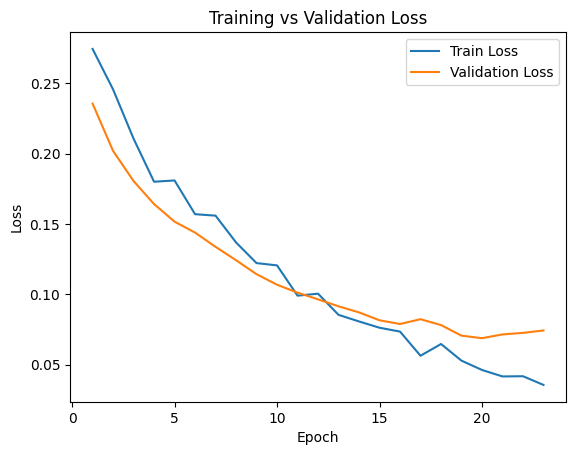

In [14]:
# %%
with open(history_path) as f:
    history = json.load(f)

train_loss = history["train_loss"]
val_loss = history["val_loss"]

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("train_vs_val_loss.png")
print("Plot saved!")
